In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle 
from centralized_solution import Cov, Cov2, solve,plot_me
import random




In [2]:
#on va appliquer avce ce premier graphe le decentralized gradient descent 
# Sélection des points 
n, m, a = 100, 10, 5
sigma=0.5
nu=1


# 1. Chargement et préparation
with open('second_database.pkl', 'rb') as f:
    x_full, y_full = pickle.load(f)

X= np.array(x_full)
Y=np.array(y_full)

x_m= np.linspace(-1,1,m)
Kmm=Cov(x_m)
Knm=Cov2(X.flatten(),x_m)


true_alpha_linalg = np.linalg.solve((sigma**2)*Kmm + Knm.T@Knm + nu*np.eye(m),Knm.T@Y.flatten())



C:\Users\BONETTI\AppData\Local\Temp\ipykernel_7568\134148796.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x_full, y_full = pickle.load(f)


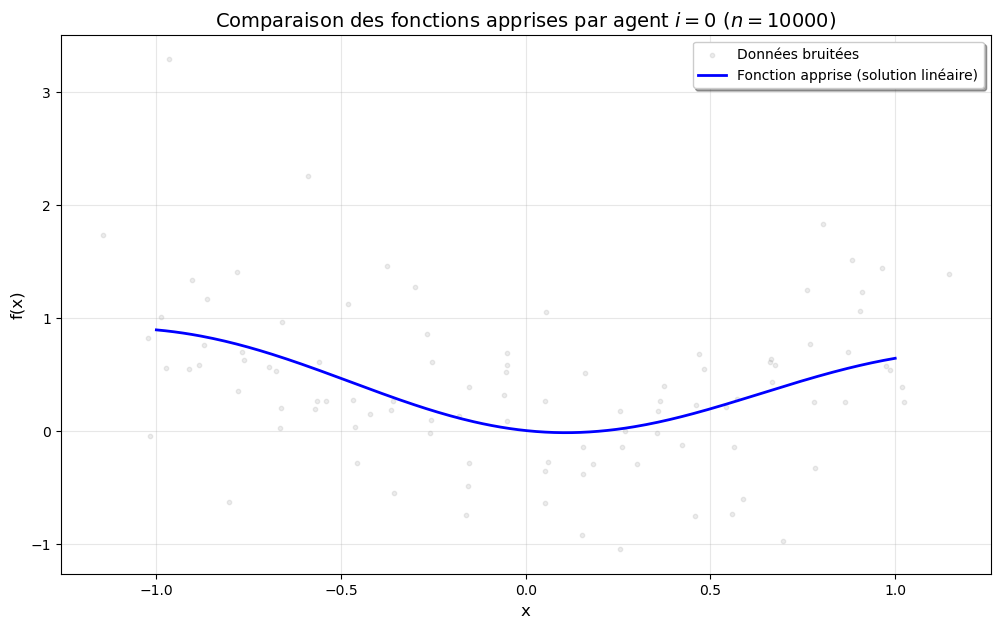

In [3]:
#visualisation de la fonction apprise 

nt = 250
x_prime = np.linspace(-1, 1, nt) # 
K_test = Cov2(x_prime, x_m) 

plt.figure(figsize=(12, 7))
plt.scatter(X, Y, alpha=0.15, s=10, label='Données bruitées', color='gray')
plt.plot(x_prime, K_test @ true_alpha_linalg, label='Fonction apprise (solution linéaire)', color='blue', linewidth=2)
plt.title(r"Comparaison des fonctions apprises par agent $i=0$ ($n=10000$)", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("f(x)", fontsize=12)
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(alpha=0.3)
plt.show()

In [4]:
## fedAvg parameters 
B=20
C=5
E1=1
E2=5
E3=50
learning_rate=0.002
nb_iterations=1000




In [11]:
def client_update_fast(X_local, Y_local, alpha_init, sigma, nu, E, B, x_m, Kmm, a,learning_rate):
    alpha = np.copy(alpha_init)
    n_i = len(X_local)
    
    for e in range(E):
        # Tirage d'un batch de taille B
        indices = np.random.choice(n_i, B, replace=False)
        X_batch, Y_batch = X_local[indices], Y_local[indices]
        
        # Calcul matriciel rapide du gradient
        Ki_batch = Cov2(X_batch, x_m) 
        # Gradient = Terme de données + Régularisation distribuée
        grad = (1/B) * Ki_batch.T @ (Ki_batch @ alpha - Y_batch) \
       + (sigma**2 / a) * Kmm @ alpha \
       + (nu / a) * alpha
        
        # Pas de descente 
        #alpha -= learning_rate * grad
        
        alpha -= (0.002/(0.01*e+1))*grad
    return alpha

def FedAvg_Final(X, Y, sigma, nu, x_m, n_rounds, E, B, C,learning_rate):
    a = len(X) # Nombre total d'agents
    m = len(x_m)
    Kmm = Cov(x_m)
    
    alpha_global = np.zeros(m)
    
    gap_history = []
    
    for r in range(n_rounds):
        # Sélection de C agents au hasard
        selected_indices = np.random.choice(a, C, replace=False)
        local_alphas = []
        
        for idx in selected_indices:
            # Mise à jour locale sur l'agent sélectionné
            a_i = client_update_fast(X[idx], Y[idx], alpha_global, 
                                     sigma, nu, E, B, x_m, Kmm, a,learning_rate)
            local_alphas.append(a_i)
        
        # Agrégation par moyenne
        alpha_global = np.mean(local_alphas, axis=0)
        
        # Suivi de l'erreur (Optimalité Gap)
        err = np.linalg.norm(alpha_global - true_alpha_linalg)
        gap_history.append(err)
        
    return alpha_global, gap_history

**variations des paramètres**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
random.seed(0)



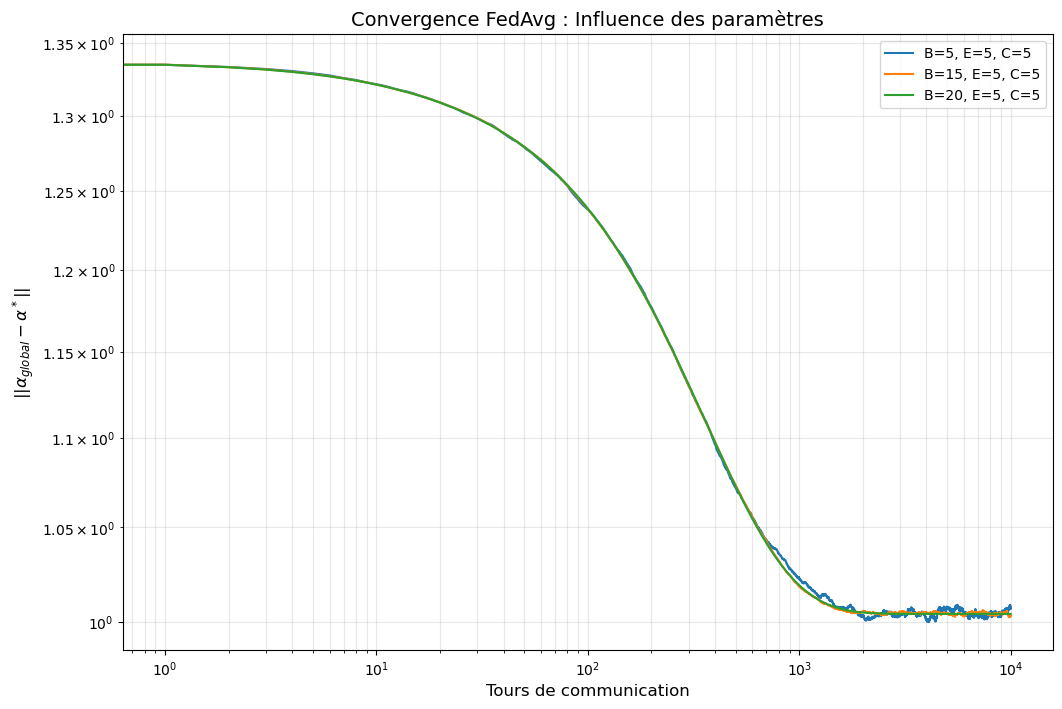

In [7]:


# Paramètres à tester
epochs_list = [1, 5, 50]
batch_sizes = [5, 15, 20]
clients_list = [2, 5]

plt.figure(figsize=(12, 8))


for b in batch_sizes:
    _, history = FedAvg_Final(X, Y, sigma, nu, x_m, n_rounds=10000, E=5, B=b, C=5,learning_rate=learning_rate  )
    plt.loglog(history, label=f'B={b}, E=5, C=5')

plt.xlabel('Tours de communication', fontsize=12) 
plt.ylabel(r'$||\alpha_{global} - \alpha^*||$', fontsize=12) 
plt.title('Convergence FedAvg : Influence des paramètres', fontsize=14)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig('FedAvg_Parameters_Comparison_batch.pdf') 
plt.show()

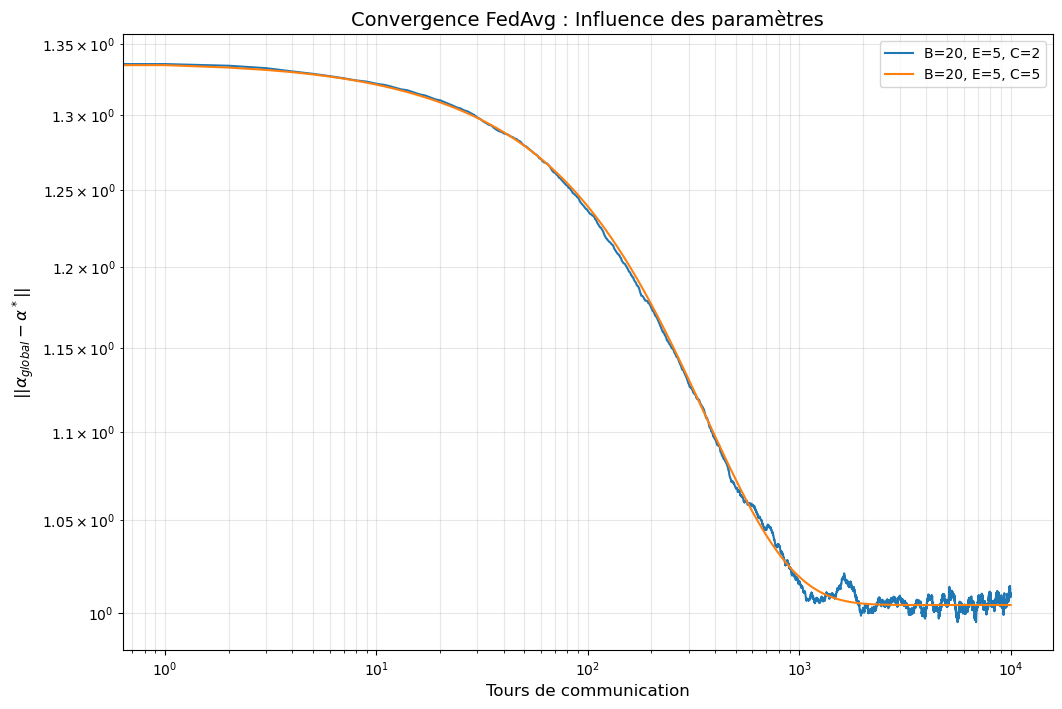

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres à tester
epochs_list = [1, 5, 50]
batch_sizes = [5, 15, 20]
clients_list = [2, 5]

plt.figure(figsize=(12, 8))


for c in clients_list:
    _, history = FedAvg_Final(X, Y, sigma, nu, x_m, n_rounds=10000, E=5, B=20, C=c,learning_rate=learning_rate  )
    plt.loglog(history, label=f'B=20, E=5, C={c}')

plt.xlabel('Tours de communication', fontsize=12) 
plt.ylabel(r'$||\alpha_{global} - \alpha^*||$', fontsize=12) 
plt.title('Convergence FedAvg : Influence des paramètres', fontsize=14)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig('FedAvg_Parameters_Comparison_clients.pdf') 
plt.show()

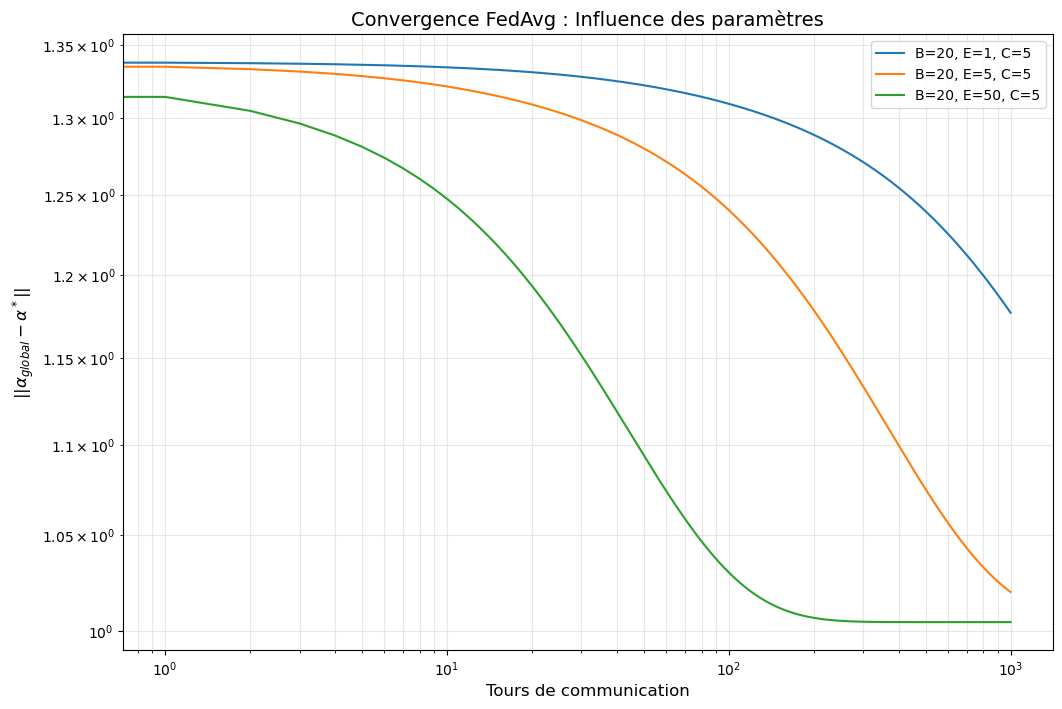

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres à tester
epochs_list = [1, 5, 50]
batch_sizes = [5, 15, 20]
clients_list = [2, 5]

plt.figure(figsize=(12, 8))


for s in epochs_list:
    _, history = FedAvg_Final(X, Y, sigma, nu, x_m, n_rounds=1000, E=s, B=20, C=5,learning_rate=learning_rate)
    plt.loglog(history, label=f'B=20, E={s}, C=5')

plt.xlabel('Tours de communication', fontsize=12) 
plt.ylabel(r'$||\alpha_{global} - \alpha^*||$', fontsize=12) 
plt.title('Convergence FedAvg : Influence des paramètres', fontsize=14)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig('FedAvg_Parameters_Comparison_epochs_no_constant.pdf') 
plt.show()